In [ ]:
!pip install torch transformers Pillow opencv-python ultralytics

In [1]:
import os
import sys
import json
import ast

from PIL import Image
import torch

from transformers import (
    SamModel,
    SamProcessor,
    AutoModelForCausalLM,
    AutoTokenizer,
    GenerationConfig,
)

from ultralytics import YOLO

2025-09-09 04:02:32.986350: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757390553.008295     713 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757390553.016037     713 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
detection_model_id = "/kaggle/working/yolo11n.pt"
detection_model = YOLO(detection_model_id)


def run_detection(image_path: str, is_visualize: bool = False):
    """
    YOLOv11: return list of {box, label, score} for a single image.
    """
    results = detection_model(image_path)
    r = results[0]

    detections = []
    for box in r.boxes:
        coords = box.xyxy.cpu().numpy().flatten().tolist()
        score = float(box.conf.cpu().numpy().item())
        cls_id = int(box.cls.cpu().numpy().item())

        detections.append({
            "box": coords,
            "label": r.names[cls_id],
            "score": score,
        })

    if is_visualize:
        r.show()

    return {"detections": detections}

In [4]:
segmentation_model_id = "facebook/sam-vit-base"
sam_processor = SamProcessor.from_pretrained(segmentation_model_id)
sam_model = SamModel.from_pretrained(segmentation_model_id)


def run_segmentation(image_path: str):
    """
    SAM: return binary masks as nested lists
    """
    img = Image.open(image_path).convert("RGB")
    inputs = sam_processor(images=img, return_tensors="pt")
    outputs = sam_model(**inputs)

    masks = outputs.pred_masks.squeeze(0).cpu().detach().numpy().tolist()
    return {"masks": masks}

In [5]:
tool_functions = {
    "run_detection": run_detection,
    "run_segmentation": run_segmentation,
}

In [6]:
functions_lst = [
    {
        "type": "function",
        "function": {
            "name": "run_detection",
            "description": "Detect objects in an image and return bounding boxes and labels.",
            "parameters": {
                "type": "object",
                "properties": {
                    "image_path": {
                        "type": "string",
                        "description": "Local path to the image file."
                    },
                    "is_visualize": {
                        "type": "boolean",
                        "description": "Flag to visualize the detection results. Default is False."
                    },
                },
                "required": ["image_path"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "run_segmentation",
            "description": "Segment objects in an image and return binary masks.",
            "parameters": {
                "type": "object",
                "properties": {
                    "image_path": {
                        "type": "string",
                        "description": "Local path to the image file."
                    },
                },
                "required": ["image_path"],
            },
        },
    },
]

In [7]:
SYSTEM_PROMPT = """
You are an expert in composing functions. You are given a question and a set of possible functions.
Based on the question, you will need to make one or more function/tool calls to achieve the purpose.
If none of the function can be used, point it out. If the given question lacks the parameters
required by the function, also point it out. You should only return the function call in tools call sections.

If you decide to invoke any of the function(s), you MUST put it in the format of 
[func_name1(params_name1=params_value1, params_name2=params_value2...), func_name2(params)]
You MUST NOT include any explanation, notes, markdown, or extra text outside the list. 
Return only the function calls list in a valid Python syntax that can be parsed with ast.parse.
Only output a valid Python list of function calls like:
[run_detection(image_path="/kaggle/working/cat.jpg")]
Do not return any cv2 code or explanations.

Here is a list of functions in JSON format that you can invoke.

{functions}
""".format(functions=functions_lst)

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "meta-llama/Llama-3.2-1B-Instruct"

llm = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map=device,
    torch_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

In [9]:
messages = [
    {
        "role": "system",
        "content": SYSTEM_PROMPT,
    },
    {
        "role": "user",
        "content": "Please detect objects in the image '/kaggle/working/cat.jpg'.",
    },
]

generation_config = GenerationConfig(
    max_new_tokens=512,
    temperature=1.0,
    top_p=0.98,
    top_k=50,
    repetition_penalty=1.2,
    do_sample=True,
    num_return_sequences=1,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.eos_token_id,
)

tokenized_chat = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_attention_mask=True,
    return_tensors="pt",
).to(device)

outputs = llm.generate(
    tokenized_chat,
    generation_config=generation_config,
)

raw = tokenizer.decode(outputs[0], skip_special_tokens=True)
tool_calls_lst_str = raw.split("assistant")[-1]

try:
    tree = ast.parse(tool_calls_lst_str, mode="eval")
    call_nodes = tree.body.elts
except SyntaxError:
    print("Cannot parse the function call. Try again.")
    sys.exit(1)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


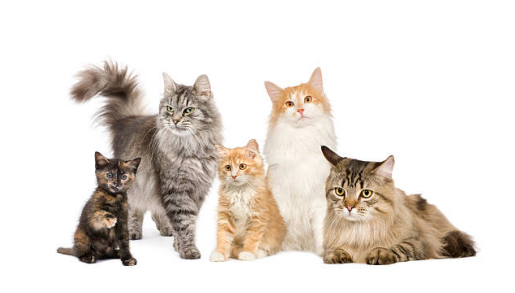

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = "/kaggle/working/cat.jpg"
img = mpimg.imread(img_path)

plt.imshow(img)
plt.axis("off")   # ẩn trục
plt.show()

In [11]:
tool_calls_result = []
for call in call_nodes:
    function_name = call.func.id
    parameters = {
        kw.arg: ast.literal_eval(kw.value)
        for kw in call.keywords
    }

    result = tool_functions[function_name](**parameters)
    tool_calls_result.append(result)

print("Tool calls results:", tool_calls_result)


image 1/1 /kaggle/working/cat.jpg: 352x640 5 cats, 55.2ms
Speed: 2.5ms preprocess, 55.2ms inference, 6.0ms postprocess per image at shape (1, 3, 352, 640)
Tool calls results: [{'detections': [{'box': [384.6571044921875, 168.74417114257812, 580.3651123046875, 314.6753234863281], 'label': 'cat', 'score': 0.8184865713119507}, {'box': [248.05154418945312, 157.90310668945312, 342.531982421875, 311.1543884277344], 'label': 'cat', 'score': 0.7662531733512878}, {'box': [57.85631561279297, 175.35533142089844, 161.02523803710938, 317.10308837890625], 'label': 'cat', 'score': 0.7463517189025879}, {'box': [153.74171447753906, 76.74353790283203, 267.21514892578125, 307.26995849609375], 'label': 'cat', 'score': 0.6707041263580322}, {'box': [312.1920471191406, 70.45621490478516, 406.7777099609375, 304.2884216308594], 'label': 'cat', 'score': 0.6252455115318298}]}]
